In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import json

In [12]:
def signed_angle(origin, target, x):
    """
    Signed angle of x relative to origin.
    Positive means toward target.
    Negative means away from target.

    Returns angle in degrees in (-180, 180].
    """
    # Build orthonormal basis of the plane
    e1 = origin / np.linalg.norm(origin)

    v = target - np.dot(target, e1) * e1
    e2 = v / np.linalg.norm(v)

    def angle(y):
        return np.arctan2(np.dot(y, e2), np.dot(y, e1))

    a0 = angle(origin)
    a1 = angle(target)
    ax = angle(x)

    wrap = lambda a: (a + np.pi) % (2 * np.pi) - np.pi

    return -np.degrees(
        np.sign(wrap(a1 - a0)) * wrap(ax - a0)
    )

In [13]:
def plot_multirun_trajectories(
    multirun_folder,
    conditions,
    colors,
    ax=None,
    pred_name='prediction',
    pred_slot='color',
    shade='std',
    x_axis='steps',
    smooth=50,
    title=None,
    size=(6,4)
):
    """
    Plot average repulsion-metric trajectories across all seeds in a multirun folder,
    split by similarity condition (subgroup).

    Parameters
    ----------
    multirun_folder : str
        Path to the multirun folder whose immediate children are per-seed run dirs.
        E.g. 'multirun/2026-06-21/23-06-16'.
    conditions : dict or list
        If dict: {subgroup_name: display_label}.
        If list: subgroup names used as their own labels.
        Only the listed subgroups are plotted; order sets the legend order.
    colors : dict or list
        If dict: {subgroup_name: matplotlib_color}.
        If list: colors aligned with the order of `conditions`.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.  A new figure is created if None.
    pred_name : str
        Stem of the evaluation probe files (default 'prediction').
    pred_slot : str
        Output-slot label appended to file names (default 'color').
    shade : {'std', 'sem', None}
        How to shade around the mean: standard deviation across seeds ('std'),
        standard error ('sem'), or no shading (None).
    x_axis : {'steps', 'index'}
        X-axis unit: training steps or checkpoint index.
    smooth : int or None
        Width of the uniform moving-average window applied to each plotted curve.
        Set to None or 1 to disable smoothing.  Default is 50.
    title : str, optional
        Axes title.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    def _smooth(arr, w):
        """Apply a causal uniform moving average of width w (1-D array)."""
        if w is None or w <= 1:
            return arr
        kernel = np.ones(w) / w
        return np.convolve(arr, kernel, mode='full')[:len(arr)]

    # Normalise conditions / colors into dicts
    if isinstance(conditions, list):
        conditions = {sg: sg for sg in conditions}
    if isinstance(colors, list):
        colors = {sg: c for sg, c in zip(conditions.keys(), colors)}

    # Discover seed subfolders (any subdirectory whose name is an integer)
    seed_dirs = sorted(
        [
            os.path.join(multirun_folder, d)
            for d in os.listdir(multirun_folder)
            if os.path.isdir(os.path.join(multirun_folder, d))
        ],
        key=lambda p: int(os.path.basename(p)) if os.path.basename(p).isdigit() else float('inf'),
    )
    if not seed_dirs:
        raise ValueError(f"No seed subdirectories found in {multirun_folder!r}")

    # Per-condition accumulator: condition → list of (n_steps,) arrays, one per seed
    cond_trajectories = {sg: [] for sg in conditions}
    common_steps = None

    for seed_dir in seed_dirs:
        pred_file  = os.path.join(seed_dir, f'{pred_name}_combined_{pred_slot}.npy')
        gt_file    = os.path.join(seed_dir, f'{pred_name}_target_{pred_slot}.npy')
        rows_file  = os.path.join(seed_dir, f'{pred_name}_rows.json')
        steps_file = os.path.join(seed_dir, f'{pred_name}_steps.npy')

        if not all(os.path.exists(p) for p in (pred_file, gt_file, rows_file, steps_file)):
            continue  # skip incomplete runs

        prediction   = np.load(pred_file)    # (n_steps, n_samples, pred_dim)
        ground_truth = np.load(gt_file)      # (n_samples, pred_dim)
        steps_arr    = np.load(steps_file)   # (n_steps,)
        with open(rows_file) as f:
            row_info = json.load(f)

        if common_steps is None:
            common_steps = steps_arr

        n_samples = ground_truth.shape[0]
        n_groups  = n_samples // 2
        item_dim  = ground_truth.shape[1] // n_groups

        # Compute repulsion metric: (n_steps, n_samples)
        metric = np.empty((len(steps_arr), n_samples))
        for t in range(len(steps_arr)):
            vals = []
            for i in range(n_groups):
                gt1   = ground_truth[2*i,   (item_dim*i):(item_dim*(i+1))]
                gt2   = ground_truth[2*i+1, (item_dim*i):(item_dim*(i+1))]
                pred1 = prediction[t, 2*i,   (item_dim*i):(item_dim*(i+1))]
                pred2 = prediction[t, 2*i+1, (item_dim*i):(item_dim*(i+1))]
                vals.extend([signed_angle(gt1, gt2, pred1),
                              signed_angle(gt2, gt1, pred2)])
            metric[t] = vals

        # Average over samples within each condition → (n_steps,)
        for sg in conditions:
            mask = np.array([r['subgroup'] == sg for r in row_info])
            if mask.any():
                cond_trajectories[sg].append(metric[:, mask].mean(axis=1))

    if common_steps is None:
        raise RuntimeError("No complete seed runs found.")

    # Plot
    if ax is None:
        _, ax = plt.subplots(figsize=size)

    x = common_steps if x_axis == 'steps' else np.arange(len(common_steps))

    for sg, label in conditions.items():
        trajs = cond_trajectories[sg]
        if not trajs:
            continue
        arr   = np.stack(trajs)          # (n_seeds, n_steps)
        mean  = _smooth(arr.mean(axis=0), smooth)
        color = colors.get(sg)

        ax.plot(x, mean, label=label, color=color)

        if shade == 'std':
            err = _smooth(arr.std(axis=0), smooth)
        elif shade == 'sem':
            err = _smooth(arr.std(axis=0) / np.sqrt(len(trajs)), smooth)
        else:
            err = None

        if err is not None:
            ax.fill_between(x, mean - err, mean + err, alpha=0.2, color=color)

    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Trials' if x_axis == 'steps' else 'Checkpoint index')
    ax.set_ylabel('Repulsion metric (degrees)')
    ax.legend()
    if title:
        ax.set_title(title)

    return ax


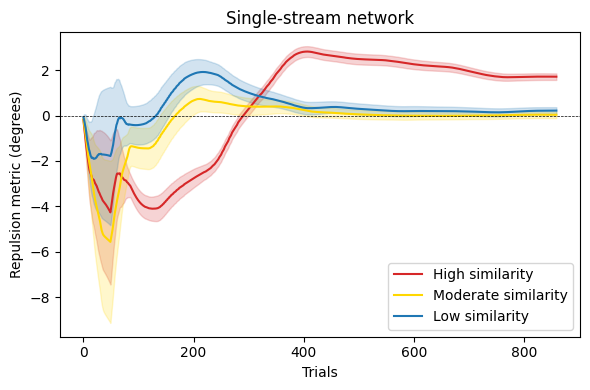

In [25]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp1/linear_network',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


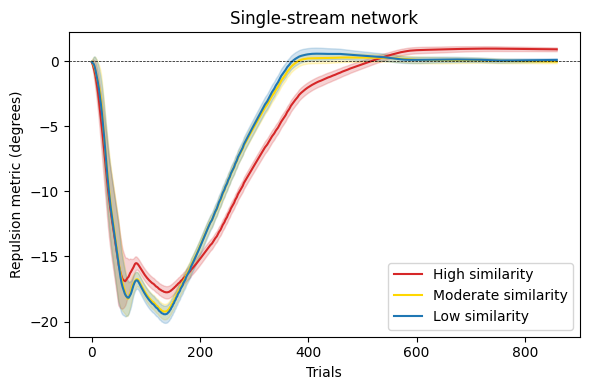

In [26]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp1/relu_network',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


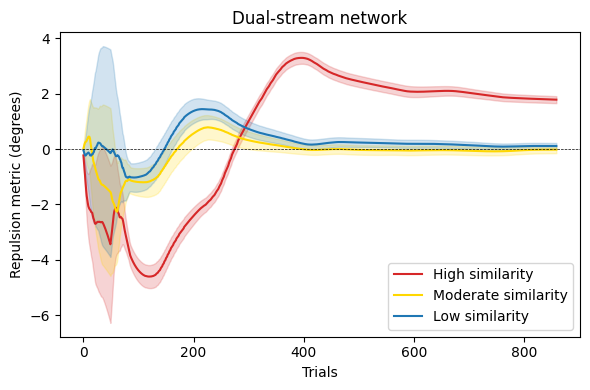

In [27]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp1/dual_stream_linear',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


In [28]:
target = np.load('../data/chanales2021_exp3/linear_network/0/prediction_target_color.npy')

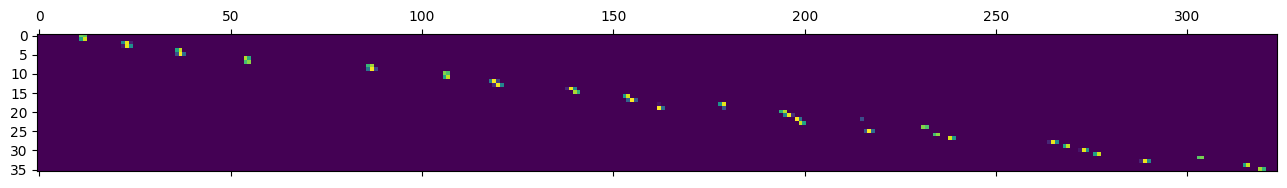

In [30]:
plt.matshow(target)

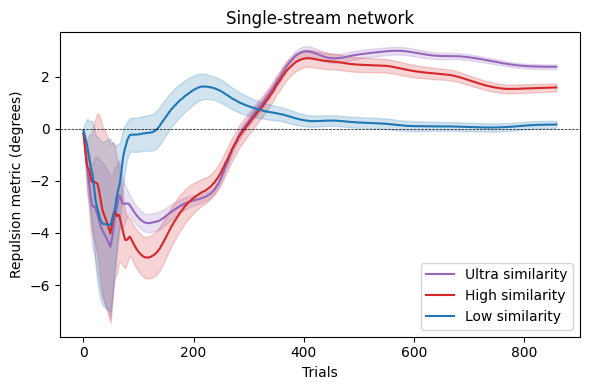

In [31]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp3/linear_network',
    conditions={'ultra_sim': 'Ultra similarity', 'high_sim': 'High similarity', 'low_sim': 'Low similarity'},
    colors={'ultra_sim': 'tab:purple', 'high_sim': 'tab:red', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


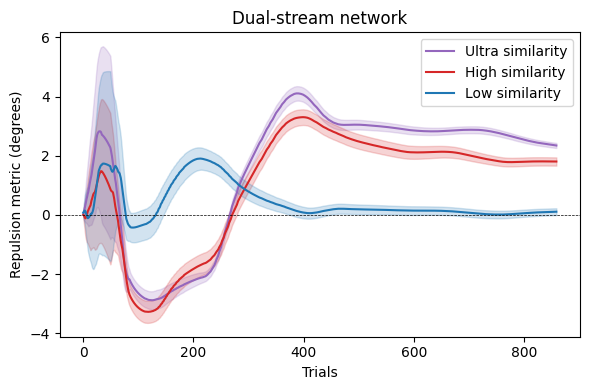

In [32]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp3/dual_stream_linear',
    conditions={'ultra_sim': 'Ultra similarity', 'high_sim': 'High similarity', 'low_sim': 'Low similarity'},
    colors={'ultra_sim': 'tab:purple', 'high_sim': 'tab:red', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


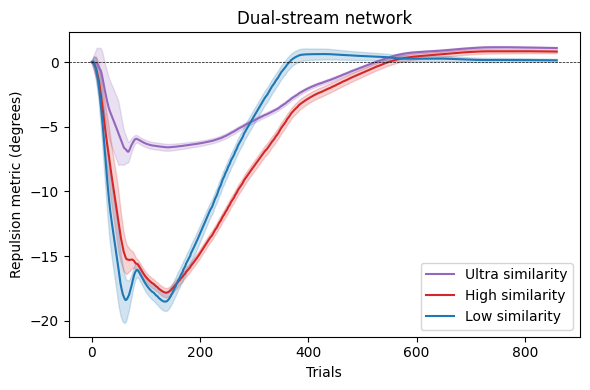

In [33]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp3/relu_network',
    conditions={'ultra_sim': 'Ultra similarity', 'high_sim': 'High similarity', 'low_sim': 'Low similarity'},
    colors={'ultra_sim': 'tab:purple', 'high_sim': 'tab:red', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


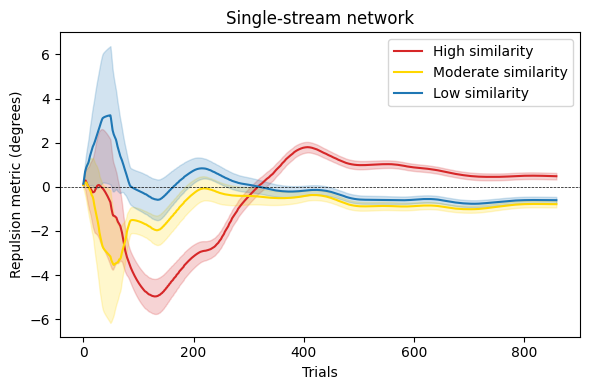

In [18]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp4/linear_network',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


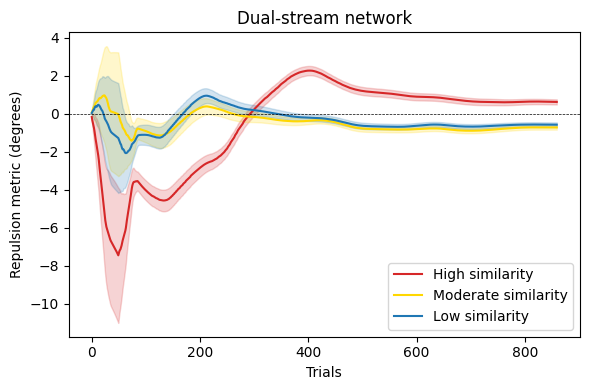

In [19]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp4/dual_stream_linear',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


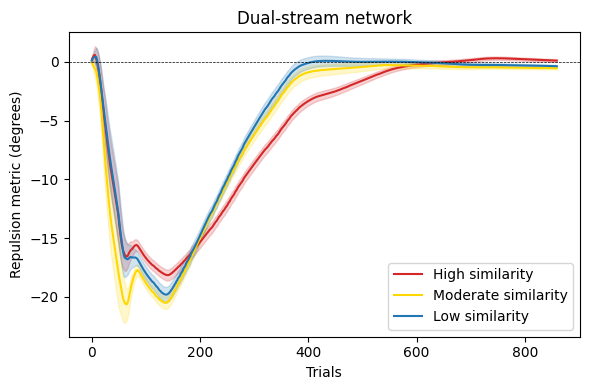

In [34]:
ax = plot_multirun_trajectories(
    '../data/chanales2021_exp4/relu_network',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


In [20]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-23/11-31-43',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '../multirun/2026-06-23/11-31-43'

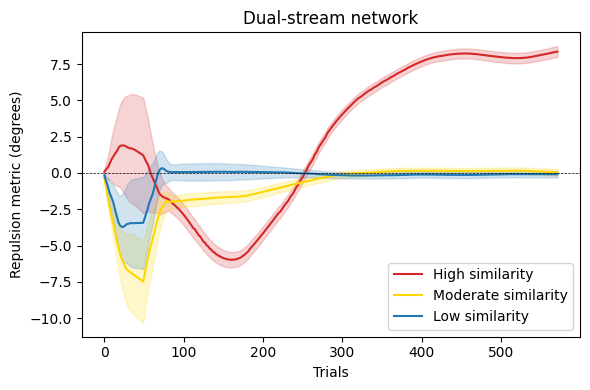

In [ ]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-21/23-21-43',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
)
plt.tight_layout()
plt.show()


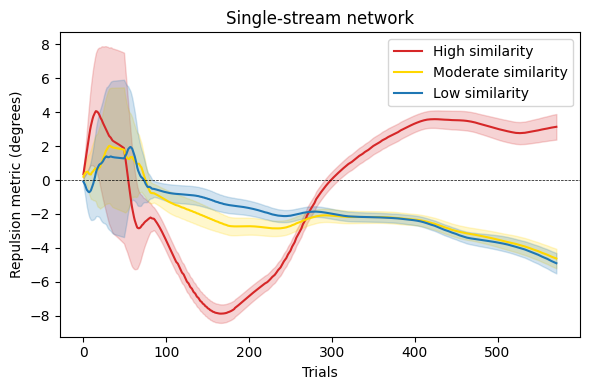

In [ ]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-22/01-50-06',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


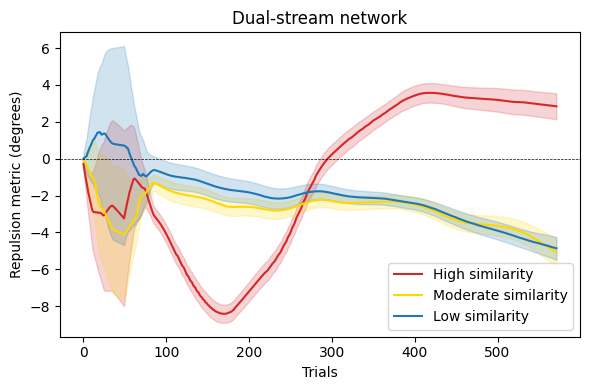

In [ ]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-22/02-10-11',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
)
plt.tight_layout()
plt.show()
